# T05 — local evaluation & cross-arm comparison

Loads per-query result bundles for **every selected PDF**, concatenates them
across the curated 5-PDF set, and compares arms on the combined
ground-truth. Per-PDF breakdowns are shown for stratification.

Runs **locally** — no GPU. T07 weighted metrics are not exercised here
(they need T03's chunk weights cache); we use the standalone functions for
binary R@k / MRR / NDCG.

Source of truth for the selected PDFs:
`RQ2_T00_ORCHESTRATOR/data/selected_pdfs.json`.

Sections:
1. Config
2. Optional — pull T05 results from Azure Blob (loops over `RUN_NAMES`)
3. Load all arms across all runs
4. Coverage check
5. Headline binary metrics (combined + per-PDF breakdown)
6. Cost summary
7. Stratified analysis
8. Significance tests
9. Cost-vs-recall plot


*— cell 1 —*

## 1. Config

In [1]:
# === cell 2 ===
from pathlib import Path

# Curated 5 PDFs (see RQ2_T00_ORCHESTRATOR/data/selected_pdfs.json).
# RUN_NAME convention: "t04_<bsard_stem>" — matches the GT filenames in
# RQ2_T07_EVALUATION/ground_truth/runs/ and the Azure notebook's RUN_NAME.
RUN_NAMES = [
    "t04_1804_03_21_1804032150",
    "t04_1867_06_08_1867060850",
    "t04_1967_10_10_1967101055",
    "t04_1967_10_10_1967101056",
    "t04_2003_07_17_2013A31614",
]

GT_DIR = Path("../RQ2_T07_EVALUATION/ground_truth/runs")


def arm_paths(run_name: str) -> dict[str, Path]:
    """Per-arm directory of q<qid>.json files for a given run.

    Layout mirrors what the Azure notebook's section 9b stages on the VM
    (`<pdf-stem>/results/q*.json`), so a single scp -r drops files
    straight into `RQ2_T05_ARM2_PAGEINDEX/data/`. The blob layout
    (`t05_results/<RUN_NAME>/q*.json`) keeps the t04_ prefix; the local
    layout strips it.

    Add T03/T04 once per-PDF bundles compatible with these RUN_NAMEs exist.
    """
    stem = run_name.removeprefix("t04_")
    return {
        "arm2b_pageindex": Path(f"data/{stem}/results"),
        # "arm2a_metadata": Path(f"../RQ2_T04_ARM2_METADATA/data/{stem}/t08_bundles/<hash>"),
        # "arm1_naive":     Path(f"../RQ2_T03_ARM1_NAIVE/data/{stem}/t08_bundles/<hash>"),
    }


QUESTION_STATUS_JSONL = Path(
    "../RQ2_T07_EVALUATION/ground_truth"
    "/question_extraction_status/questions_by_extraction_status.jsonl"
)

# Optional: pull T05 results from Azure Blob. Toggle after each Azure run.
AZURE_CONTAINER_SAS_URL = ""
DOWNLOAD_T05 = False

print(f"Eval set: {len(RUN_NAMES)} runs")
for rn in RUN_NAMES:
    gt_p = GT_DIR / f"{rn}.json"
    print(f"  {rn:<35}  GT {'present' if gt_p.exists() else 'MISSING'}")


Eval set: 5 runs
  t04_1804_03_21_1804032150            GT present
  t04_1867_06_08_1867060850            GT present
  t04_1967_10_10_1967101055            GT present
  t04_1967_10_10_1967101056            GT present
  t04_2003_07_17_2013A31614            GT present


## 2. Optional — pull T05 results from Azure Blob

Loops over every `RUN_NAME` in §1 and downloads `t05_results/<run>/q*.json`
into `data/results/<run>/`. Idempotent. Toggle `DOWNLOAD_T05 = True` after
the Azure run for that PDF completes (or after the last of the 5).


In [2]:
# === cell 4 ===
if DOWNLOAD_T05:
    from azure.storage.blob import ContainerClient

    container = ContainerClient.from_container_url(AZURE_CONTAINER_SAS_URL)
    total_pulled = 0
    for run_name in RUN_NAMES:
        prefix = f"t05_results/{run_name}/"
        # Strip the t04_ prefix so the local target matches the layout
        # `arm_paths` resolves (data/<stem>/results/q*.json).
        stem = run_name.removeprefix("t04_")
        target = Path(f"data/{stem}/results")
        target.mkdir(parents=True, exist_ok=True)
        pulled = 0
        for blob in container.list_blobs(name_starts_with=prefix):
            name = blob.name.rsplit("/", 1)[-1]
            if not name.startswith("q") or not name.endswith(".json"):
                continue
            out = target / name
            if out.exists():
                continue
            with out.open("wb") as f:
                f.write(container.get_blob_client(blob).download_blob().readall())
            pulled += 1
        total_pulled += pulled
        print(f"  {run_name}: pulled {pulled} files to {target}")
    print(f"\nDownloaded {total_pulled} files total")
else:
    print("Skipping blob download (DOWNLOAD_T05=False).")


Skipping blob download (DOWNLOAD_T05=False).


## 3. Load per-query results from each arm × run

BSARD question_ids are globally unique across PDFs, so we flatten
`(run, qid) → result` into `arm → {qid: result}` and keep `run_name`
on the result for later groupings.


In [3]:
# === cell 6 ===
import json
from dataclasses import dataclass


@dataclass
class LoadedResult:
    query_id: str
    query_text: str
    ranked_items: list   # raw dicts as written by run_subset
    cost: dict
    method: str
    run_name: str        # which RUN_NAME this query was scored under


def load_arm_run(path: Path, run_name: str) -> dict[str, LoadedResult]:
    out: dict[str, LoadedResult] = {}
    if not path.exists():
        return out
    for fp in sorted(path.glob("q*.json")):
        d = json.loads(fp.read_text(encoding="utf-8"))
        out[str(d["query_id"])] = LoadedResult(
            query_id=str(d["query_id"]),
            query_text=d.get("query_text", ""),
            ranked_items=d.get("ranked_items", []),
            cost=d.get("cost", {}) or {},
            method=d.get("method", "?"),
            run_name=run_name,
        )
    return out


# Flatten across runs: arm -> {qid: LoadedResult}. qids are globally unique.
results_by_arm: dict[str, dict[str, LoadedResult]] = {}
for run_name in RUN_NAMES:
    for arm, path in arm_paths(run_name).items():
        loaded = load_arm_run(path, run_name)
        results_by_arm.setdefault(arm, {}).update(loaded)

# Coverage per (run, arm).
print(f"{'run_name':<35}  {'arm':<20}  {'n_q':>5}  path")
print("-" * 90)
for run_name in RUN_NAMES:
    for arm, path in arm_paths(run_name).items():
        n = sum(
            1 for r in results_by_arm.get(arm, {}).values()
            if r.run_name == run_name
        )
        marker = "ok " if path.exists() else "MISS"
        print(f"{run_name:<35}  {arm:<20}  {n:>5}  {marker} {path}")


run_name                             arm                     n_q  path
------------------------------------------------------------------------------------------
t04_1804_03_21_1804032150            arm2b_pageindex         216  ok  data\1804_03_21_1804032150\results
t04_1867_06_08_1867060850            arm2b_pageindex          57  ok  data\1867_06_08_1867060850\results
t04_1967_10_10_1967101055            arm2b_pageindex         197  ok  data\1967_10_10_1967101055\results
t04_1967_10_10_1967101056            arm2b_pageindex          71  ok  data\1967_10_10_1967101056\results
t04_2003_07_17_2013A31614            arm2b_pageindex         133  ok  data\2003_07_17_2013A31614\results


## 4. Coverage check

Merge GT across all 5 RUN_NAMEs and check whether each arm covers it.


In [4]:
# === cell 8 ===
gt: dict[str, list[int]] = {}
gt_by_run: dict[str, set[str]] = {}
for run_name in RUN_NAMES:
    gt_path = GT_DIR / f"{run_name}.json"
    if not gt_path.exists():
        print(f"  WARNING: missing GT {gt_path}")
        continue
    sub = json.loads(gt_path.read_text(encoding="utf-8"))
    overlap = set(sub.keys()) & set(gt.keys())
    if overlap:
        print(
            f"  WARNING: {len(overlap)} qids in {gt_path.name} also appear in "
            f"earlier GT files (sample: {sorted(overlap)[:5]}). "
            "Later run wins."
        )
    gt.update(sub)
    gt_by_run[run_name] = set(sub.keys())

gt_qids = set(gt.keys())
print(f"\nGT subset size (5 PDFs combined): {len(gt_qids)} questions")
for run_name, qids in gt_by_run.items():
    print(f"  {run_name:<35}  {len(qids):>4} questions")

print()
for arm, results in results_by_arm.items():
    have = set(results.keys())
    missing = sorted(gt_qids - have)
    extra = sorted(have - gt_qids)
    print(f"  {arm}: {len(have):>4} loaded, missing {len(missing):>4}, extra {len(extra):>4}")
    if missing:
        print(f"    missing sample: {missing[:10]}")



GT subset size (5 PDFs combined): 674 questions
  t04_1804_03_21_1804032150             252 questions
  t04_1867_06_08_1867060850              65 questions
  t04_1967_10_10_1967101055             204 questions
  t04_1967_10_10_1967101056              71 questions
  t04_2003_07_17_2013A31614             133 questions

  arm2b_pageindex:  674 loaded, missing    0, extra    0


## 5. Headline binary metrics

R@k / MRR@10 / NDCG@10 averaged across the combined GT-covered intersection
of all 5 PDFs, plus a per-PDF R@10 breakdown.


In [5]:
# === cell 10 ===
import numpy as np
import pandas as pd


def ranked_bsard_ids(items: list) -> list[int]:
    seen: set[int] = set()
    out: list[int] = []
    for it in items:
        bid = (it.get("metadata") or {}).get("bsard_id")
        if bid is None:
            continue
        bid_int = int(bid)
        if bid_int in seen:
            continue
        seen.add(bid_int)
        out.append(bid_int)
    return out


def recall_at_k(ranked: list[int], gt_set: set[int], k: int) -> float:
    if not gt_set:
        return 0.0
    return len(set(ranked[:k]) & gt_set) / len(gt_set)


def mrr_at_k(ranked: list[int], gt_set: set[int], k: int) -> float:
    for i, b in enumerate(ranked[:k]):
        if b in gt_set:
            return 1.0 / (i + 1)
    return 0.0


def ndcg_at_k(ranked: list[int], gt_set: set[int], k: int) -> float:
    gains = [1.0 if b in gt_set else 0.0 for b in ranked[:k]]
    dcg = sum(g / np.log2(i + 2) for i, g in enumerate(gains))
    ideal = sorted(gains, reverse=True)
    idcg = sum(g / np.log2(i + 2) for i, g in enumerate(ideal))
    return dcg / idcg if idcg > 0 else 0.0


KS = (1, 5, 10, 20, 100)
METRIC_COLS = [f"R@{k}" for k in KS] + ["MRR@10", "NDCG@10"]


def per_query_metrics(arm_results: dict[str, LoadedResult]) -> pd.DataFrame:
    rows = []
    for qid, gt_bids in gt.items():
        if qid not in arm_results:
            continue
        r = arm_results[qid]
        ranked = ranked_bsard_ids(r.ranked_items)
        gt_set = {int(b) for b in gt_bids}
        rec = {"query_id": qid, "run_name": r.run_name}
        for k in KS:
            rec[f"R@{k}"] = recall_at_k(ranked, gt_set, k)
        rec["MRR@10"] = mrr_at_k(ranked, gt_set, 10)
        rec["NDCG@10"] = ndcg_at_k(ranked, gt_set, 10)
        rows.append(rec)
    if not rows:
        # Empty arm — return an empty frame with the expected schema so
        # downstream callers can keep using `.empty`, `.groupby`, and
        # column access without special-casing.
        empty = pd.DataFrame(columns=["run_name"] + METRIC_COLS)
        empty.index.name = "query_id"
        return empty
    return pd.DataFrame(rows).set_index("query_id")


per_query_by_arm = {
    arm: per_query_metrics(results) for arm, results in results_by_arm.items()
}

print("Headline (all 5 PDFs combined):")
agg_rows = []
for arm, pq in per_query_by_arm.items():
    if pq.empty:
        continue
    agg_rows.append({"arm": arm, "n_q": len(pq), **pq[METRIC_COLS].mean().to_dict()})
display(pd.DataFrame(agg_rows).set_index("arm").round(4))

print("\nR@10 per PDF × arm:")
breakdown_rows = []
for arm, pq in per_query_by_arm.items():
    if pq.empty:
        continue
    for run_name, slice_ in pq.groupby("run_name"):
        breakdown_rows.append({
            "run_name": run_name,
            "arm": arm,
            "n_q": len(slice_),
            "R@10": float(slice_["R@10"].mean()),
        })
if breakdown_rows:
    bdf = pd.DataFrame(breakdown_rows)
    display(bdf.pivot(index="run_name", columns="arm", values="R@10").round(4))


Headline (all 5 PDFs combined):


,n_q,R@1,R@5,R@10,R@20,R@100,MRR@10,NDCG@10
arm,,,,,,,,
arm2b_pageindex,674,0.0686,0.1363,0.1736,0.2194,0.408,0.1807,0.1967



R@10 per PDF × arm:


arm,arm2b_pageindex
run_name,
t04_1804_03_21_1804032150,0.1622
t04_1867_06_08_1867060850,0.1404
t04_1967_10_10_1967101055,0.1216
t04_1967_10_10_1967101056,0.0999
t04_2003_07_17_2013A31614,0.3226


*— cell 11 —*

## 6. Cost summary\n\nLLM calls, tokens, latency. Zero LLM cost for T03/T04.

In [6]:
# === cell 12 ===
cost_rows = []
for arm, results in results_by_arm.items():
    calls = [r.cost.get("llm_calls", 0) for r in results.values()]
    latencies = [r.cost.get("latency_ms", 0.0) for r in results.values()]
    tok_in = [r.cost.get("tokens_in", 0) for r in results.values()]
    tok_out = [r.cost.get("tokens_out", 0) for r in results.values()]
    parse_fail = [r.cost.get("parse_failures", 0) for r in results.values()]
    cost_rows.append({
        "arm": arm,
        "n_q": len(results),
        "calls/q": np.mean(calls) if calls else 0.0,
        "tok_in/q": np.mean(tok_in) if tok_in else 0.0,
        "tok_out/q": np.mean(tok_out) if tok_out else 0.0,
        "lat_p50_ms": float(np.median(latencies)) if latencies else 0.0,
        "lat_p95_ms": float(np.percentile(latencies, 95)) if latencies else 0.0,
        "lat_total_s": sum(latencies) / 1000.0,
        "parse_fail_total": sum(parse_fail),
    })
print("Cost (all 5 PDFs combined):")
display(pd.DataFrame(cost_rows).set_index("arm").round(2))

print("\nLLM calls/q per PDF × arm:")
cost_breakdown = []
for arm, results in results_by_arm.items():
    by_run: dict[str, list[float]] = {}
    for r in results.values():
        by_run.setdefault(r.run_name, []).append(r.cost.get("llm_calls", 0))
    for run_name, calls in by_run.items():
        cost_breakdown.append({
            "run_name": run_name, "arm": arm, "n_q": len(calls),
            "calls/q": float(np.mean(calls)) if calls else 0.0,
        })
if cost_breakdown:
    cdf = pd.DataFrame(cost_breakdown)
    display(cdf.pivot(index="run_name", columns="arm", values="calls/q").round(2))


Cost (all 5 PDFs combined):


,n_q,calls/q,tok_in/q,tok_out/q,lat_p50_ms,lat_p95_ms,lat_total_s,parse_fail_total
arm,,,,,,,,
arm2b_pageindex,674,5.83,18201.29,651.9,37813.78,54894.56,25947.29,1



LLM calls/q per PDF × arm:


arm,arm2b_pageindex
run_name,
t04_1804_03_21_1804032150,5.78
t04_1867_06_08_1867060850,6.21
t04_1967_10_10_1967101055,6.25
t04_1967_10_10_1967101056,5.42
t04_2003_07_17_2013A31614,5.34


## 7. Stratified analysis

Three cuts:

1. **By BSARD `extraction_status`** — exact / partial / mixed / not_present.
2. **By `n_relevant_bsard_articles`** — single-article queries (1) vs
   multi-article (2-3, 4+). Multi-article is where T05's
   cross-reference-following is meant to pay off.
3. **By source PDF (`run_name`)** — drift-aware coverage varies (84.9%
   on 2003A31614, 97.8% on 1967101056); per-PDF means flag the
   PDFs where the GT just isn't there.


In [7]:
# === cell 14 ===
status_df = pd.read_json(QUESTION_STATUS_JSONL, lines=True)
status_df["question_id"] = status_df["question_id"].astype(str)
status_df = status_df[status_df["question_id"].isin(gt_qids)].copy()
status_df["n_bucket"] = status_df["n_relevant_bsard_articles"].apply(
    lambda n: "1" if n == 1 else ("2-3" if n <= 3 else "4+")
)
print(f"Stratification base: {len(status_df)} questions matching GT across {len(RUN_NAMES)} runs")


def stratify(field: str, df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for value in sorted(df[field].unique()):
        qids = set(df[df[field] == value]["question_id"])
        for arm, pq in per_query_by_arm.items():
            slice_ = pq[pq.index.isin(qids)]
            rows.append({
                field: value,
                "arm": arm,
                "n_q": len(slice_),
                "R@10": float(slice_["R@10"].mean()) if len(slice_) else float("nan"),
                "MRR@10": float(slice_["MRR@10"].mean()) if len(slice_) else float("nan"),
            })
    return pd.DataFrame(rows)


print("\nBy extraction_status (R@10):")
display(
    stratify("extraction_status", status_df)
    .pivot(index="extraction_status", columns="arm", values="R@10")
    .round(4)
)

print("\nBy n_relevant_bsard_articles bucket (R@10):")
display(
    stratify("n_bucket", status_df)
    .pivot(index="n_bucket", columns="arm", values="R@10")
    .round(4)
)

# Cross-cut: extraction_status × source PDF for a single arm — diagnoses
# whether weakness on a PDF is drift-driven or method-driven.
print("\nR@10 by (run_name × extraction_status) for arm2b_pageindex:")
pq = per_query_by_arm.get("arm2b_pageindex")
if pq is not None and not pq.empty:
    joined = pq.join(
        status_df.set_index("question_id")[["extraction_status"]],
        how="left",
    )
    display(
        joined.groupby(["run_name", "extraction_status"])["R@10"]
        .mean().unstack("extraction_status").round(4)
    )


Stratification base: 674 questions matching GT across 5 runs

By extraction_status (R@10):


arm,arm2b_pageindex
extraction_status,
exact,0.1367
mixed,0.1242
partial,0.3519



By n_relevant_bsard_articles bucket (R@10):


arm,arm2b_pageindex
n_bucket,
1,0.2805
2-3,0.1592
4+,0.1173



R@10 by (run_name × extraction_status) for arm2b_pageindex:


extraction_status,exact,mixed,partial
run_name,,,
t04_1804_03_21_1804032150,0.1485,0.1160,0.7778
t04_1867_06_08_1867060850,0.1351,0.1500,NaN
t04_1967_10_10_1967101055,0.1699,0.0967,0.1250
t04_1967_10_10_1967101056,0.0357,0.1614,0.1667
t04_2003_07_17_2013A31614,NaN,0.2271,0.3436


*— cell 15 —*

## 8. Pairwise significance tests on R@10

Paired t-test + Wilcoxon signed-rank, restricted to queries shared by
both arms in each pair. Skipped when fewer than 5 paired observations.

In [8]:
# === cell 16 ===
arms = list(per_query_by_arm.keys())
sig_rows = []
if len(arms) < 2:
    print("Need at least two arms with results — skipping significance.")
else:
    from scipy.stats import ttest_rel, wilcoxon

    for i, a in enumerate(arms):
        for b in arms[i + 1 :]:
            shared = per_query_by_arm[a].index.intersection(per_query_by_arm[b].index)
            if len(shared) < 5:
                sig_rows.append({"a": a, "b": b, "n": len(shared), "note": "<5 paired obs"})
                continue
            x = per_query_by_arm[a].loc[shared, "R@10"].to_numpy()
            y = per_query_by_arm[b].loc[shared, "R@10"].to_numpy()
            t_stat, p_t = ttest_rel(x, y)
            try:
                w_stat, p_w = wilcoxon(x, y)
            except ValueError:
                w_stat, p_w = float("nan"), 1.0
            sig_rows.append({
                "a": a, "b": b, "n": int(len(shared)),
                "mean_a": float(x.mean()), "mean_b": float(y.mean()),
                "ttest_p": float(p_t), "wilcoxon_p": float(p_w),
            })

pd.DataFrame(sig_rows).round(4) if sig_rows else "no pairs"


Need at least two arms with results — skipping significance.


'no pairs'

*— cell 17 —*

## 9. Cost-vs-recall plot\n\nVisualises the trade-off T05 makes against the zero-LLM arms.

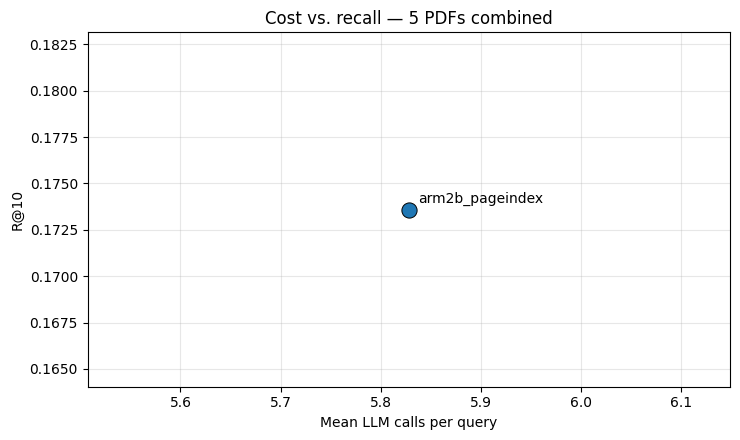

In [9]:
# === cell 18 ===
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7.5, 4.5))
cost_lookup = {row["arm"]: row for row in cost_rows}
for arm, pq in per_query_by_arm.items():
    if pq.empty or arm not in cost_lookup:
        continue
    r10 = float(pq["R@10"].mean())
    calls = float(cost_lookup[arm]["calls/q"])
    ax.scatter(calls, r10, s=120, edgecolors="black", linewidths=0.7)
    ax.annotate(
        arm, (calls, r10),
        fontsize=10, xytext=(7, 5), textcoords="offset points",
    )
ax.set_xlabel("Mean LLM calls per query")
ax.set_ylabel("R@10")
ax.set_title(f"Cost vs. recall — {len(RUN_NAMES)} PDFs combined")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 10. Post-fix review — before vs after

Side-by-side diagnostics for a single PDF. Point `REVIEW_RUN_NAME` at the
PDF you re-ran on Azure; `BEFORE_DIR` is the snapshot of the pre-fix
results (e.g. `results_pre_fix_2026_05_29/`), `AFTER_DIR` the canonical
`results/` dir that the Azure re-run repopulates.

For each pool the cell prints:

- **exit_reason distribution** — `no_candidates` collapsing toward zero
  is the headline win for fixes #1+#2+#3.
- **ranked items** — empty rate (was 100% on 1804, 54-89% elsewhere),
  mean ranking size (now inflated by R@100 padding so isn't a fairness
  signal on its own), and the count of items with `score > 0` (= LLM
  actually picked them; the real measure of LLM throughput).
- **foreign-LAW chapter IDs** — the LAW_2/3/4 hallucination pattern
  (was 100% of 1804 queries pre-fix) should drop to ~0.
- **list[dict] JSON shape** — the 1804-specific response-shape bug
  (was 252/252) should drop too.
- **R@K** — recall against the GT for this run, at every k in `KS`.
- **cost** — calls/q, mean tokens_in, p50/p95 latency. The new
  `num_ctx=16384` lets longer prompts actually reach the model, so
  tokens_in goes up and latency rises proportionally.

Re-run §3 → §8 → this cell after the Azure re-run completes and the
download cell has overwritten `data/<stem>/results/`. The cell loads
both directories directly from disk, independent of the rest of the
notebook's multi-PDF aggregation.


In [10]:
# === cell 20 ===
import json
import re
from collections import Counter
from pathlib import Path

# Tweak between PDFs as you re-run them on Azure.
REVIEW_RUN_NAME = "t04_2003_07_17_2013A31614"
REVIEW_STEM = REVIEW_RUN_NAME.removeprefix("t04_")
EXPECTED_LAW = {
    "t04_1804_03_21_1804032150": "LAW_9",
    "t04_1867_06_08_1867060850": "LAW_6",
    "t04_1967_10_10_1967101055": "LAW_7",
    "t04_1967_10_10_1967101056": "LAW_5",
    "t04_2003_07_17_2013A31614": "LAW_8",
}[REVIEW_RUN_NAME]

PRE_FIX_DIR_NAME = {
    "t04_1804_03_21_1804032150": "results_pre_fix_2026_05_29",
    "t04_1867_06_08_1867060850": "results_pre_fix_2026_05_29",
    "t04_1967_10_10_1967101055": "results_pre_fix_2026_05_30",
    "t04_1967_10_10_1967101056": "results_pre_fix_2026_05_30",
    "t04_2003_07_17_2013A31614": "results_pre_fix_2026_05_30",
}.get(REVIEW_RUN_NAME, "results_pre_fix_2026_05_29")

POOLS = {
    "BEFORE": Path(f"data/{REVIEW_STEM}/{PRE_FIX_DIR_NAME}"),
    "AFTER":  Path(f"data/{REVIEW_STEM}/results"),
}

review_gt = json.loads(
    (GT_DIR / f"{REVIEW_RUN_NAME}.json").read_text(encoding="utf-8")
)
gt_qids_review = set(review_gt.keys())
law_pat = re.compile(r"LAW_(\d+)")
expected_law_n = int(EXPECTED_LAW.split("_")[1])


def diagnose(pool_dir: Path) -> dict:
    files = sorted(pool_dir.glob("q*.json")) if pool_dir.exists() else []
    out = {
        "dir": str(pool_dir), "n_files": len(files),
        "exit": Counter(), "empty_rankings": 0,
        "n_ranked_total": 0, "n_ranked_score_gt0": 0,
        "foreign_law_steps": 0, "list_dict_steps": 0, "chap_steps": 0,
        "recall": {k: [] for k in KS},
        "calls_per_q": [], "tokens_in": [], "latency_ms": [],
        "missing_qids": set(gt_qids_review),
    }
    for fp in files:
        d = json.loads(fp.read_text(encoding="utf-8"))
        qid = str(d["query_id"])
        out["missing_qids"].discard(qid)
        items = d.get("ranked_items", []) or []
        if not items: out["empty_rankings"] += 1
        out["n_ranked_total"] += len(items)
        out["n_ranked_score_gt0"] += sum(1 for it in items if (it.get("score") or 0) > 0)
        cost = d.get("cost", {}) or {}
        out["exit"][cost.get("exit_reason", "?")] += 1
        out["calls_per_q"].append(cost.get("llm_calls", 0))
        out["tokens_in"].append(cost.get("tokens_in", 0))
        out["latency_ms"].append(cost.get("latency_ms", 0.0))
        if qid in review_gt:
            ranked = ranked_bsard_ids(items)
            gt_set = {int(b) for b in review_gt[qid]}
            for k in KS:
                out["recall"][k].append(recall_at_k(ranked, gt_set, k))
        for s in (d.get("trace") or {}).get("steps", []):
            if not str(s.get("step", "")).startswith("chapter_selection"): continue
            if s.get("skipped"): continue
            out["chap_steps"] += 1
            parsed = s.get("parsed")
            picked_chapter_ids: list[str] = []
            if isinstance(parsed, list):
                out["list_dict_steps"] += 1
                for item in parsed:
                    if isinstance(item, dict):
                        picked_chapter_ids.extend(item.get("selected_chapter_ids") or [])
            elif isinstance(parsed, dict):
                picked_chapter_ids.extend(parsed.get("selected_chapter_ids") or [])
            if any((m := law_pat.match(cid or "")) and int(m.group(1)) != expected_law_n
                   for cid in picked_chapter_ids):
                out["foreign_law_steps"] += 1
    return out


def fmt_pct(n: int, d: int) -> str:
    return f"{n}/{d} ({100*n/max(d,1):.1f}%)"


print(f"Reviewing run: {REVIEW_RUN_NAME}  (expected law namespace: {EXPECTED_LAW})")
print(f"GT size:       {len(review_gt)} questions\n")

reviews = {label: diagnose(p) for label, p in POOLS.items()}

rows = []
for label, r in reviews.items():
    n = r["n_files"]
    rows.append({
        "pool": label, "files": n, "missing_vs_GT": len(r["missing_qids"]),
        "empty_rank": fmt_pct(r["empty_rankings"], n),
        "mean_n_ranked": round(r["n_ranked_total"] / max(n, 1), 2),
        "mean_score>0": round(r["n_ranked_score_gt0"] / max(n, 1), 2),
        "no_candidates": fmt_pct(r["exit"].get("no_candidates", 0), n),
        "list_dict_chap": fmt_pct(r["list_dict_steps"], r["chap_steps"]),
        "foreign_LAW_chap": fmt_pct(r["foreign_law_steps"], r["chap_steps"]),
        "calls/q": round(np.mean(r["calls_per_q"]) if r["calls_per_q"] else 0, 2),
        "tok_in/q": round(np.mean(r["tokens_in"]) if r["tokens_in"] else 0, 0),
        "lat_p50_ms": round(np.median(r["latency_ms"]) if r["latency_ms"] else 0, 0),
        "lat_p95_ms": round(np.percentile(r["latency_ms"], 95) if r["latency_ms"] else 0, 0),
    })
display(pd.DataFrame(rows).set_index("pool"))

recall_rows = []
for label, r in reviews.items():
    rec = {"pool": label}
    for k in KS:
        vals = r["recall"][k]
        rec[f"R@{k}"] = round(float(np.mean(vals)), 4) if vals else float("nan")
    recall_rows.append(rec)
print("\nRecall@K vs GT:")
display(pd.DataFrame(recall_rows).set_index("pool"))

print("\nExit-reason distribution:")
exits = pd.DataFrame({label: dict(r["exit"]) for label, r in reviews.items()}).fillna(0).astype(int).T
display(exits)

for label, r in reviews.items():
    if r["n_files"] == 0:
        print(f"\n  !! {label} pool at {r['dir']} is empty.")


Reviewing run: t04_2003_07_17_2013A31614  (expected law namespace: LAW_8)
GT size:       133 questions



,files,missing_vs_GT,empty_rank,mean_n_ranked,mean_score>0,no_candidates,list_dict_chap,foreign_LAW_chap,calls/q,tok_in/q,lat_p50_ms,lat_p95_ms
pool,,,,,,,,,,,,
BEFORE,133,0,119/133 (89.5%),0.14,0.14,109/133 (82.0%),0/133 (0.0%),0/133 (0.0%),3.70,5023.0,14879.0,25049.0
AFTER,133,0,0/133 (0.0%),100.00,3.13,3/133 (2.3%),0/133 (0.0%),0/133 (0.0%),5.34,13184.0,26866.0,38689.0



Recall@K vs GT:


,R@1,R@5,R@10,R@20,R@100
pool,,,,,
BEFORE,0.0256,0.0286,0.0286,0.0286,0.0286
AFTER,0.2224,0.3000,0.3226,0.3226,0.4768



Exit-reason distribution:


,no_candidates,sufficient,parse_fail
BEFORE,109,23,1
AFTER,3,129,1
